## Load and Explore the Dataset

In [66]:
import pandas as pd
import numpy as np

In [62]:
df = pd.read_csv('./data/Superstore (1).csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1.0,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2.0,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3.0,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4.0,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5.0,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9800.000000,9789.000000,9800.000000,9994.000000,9994.000000,9994.000000
mean,4900.500000,55273.322403,230.769059,3.789574,0.156203,28.656896
std,2829.160653,32041.223413,626.651875,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2450.750000,23223.000000,17.248000,2.000000,0.000000,1.728750
50%,4900.500000,58103.000000,54.490000,3.000000,0.200000,8.666500
75%,7350.250000,90008.000000,210.605000,5.000000,0.200000,29.364000
max,9800.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [6]:
# check for duplicates
duplicates = df.duplicated().sum()
duplicates

np.int64(2)

### How much total sales? 

In [8]:
df['Sales'].sum()

np.float64(2261536.7827)

### Which Category generates the most sales?

In [14]:
max_category = df.groupby('Category')['Sales'].sum().idxmax()
print(f"The category that generates the most sales is: {max_category}")

The category that generates the most sales is: Technology


In [ ]:
# sort the categories by sales
df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

### Sales And Profit by Category

In [16]:
sap_category = df.groupby('Category')[['Sales', 'Profit']].sum()
sap_category

,Sales,Profit
Category,,
Furniture,728658.5757,16921.6842
Office Supplies,705422.3340,118956.3861
Technology,827455.8730,143100.5405


In [23]:
# using a pivot table
sap_category_pt = df.pivot_table(index='Category', values=['Sales', 'Profit'], aggfunc='sum')
sap_category_pt

,Profit,Sales
Category,,
Furniture,16921.6842,728658.5757
Office Supplies,118956.3861,705422.3340
Technology,143100.5405,827455.8730


### Sales and Profit by Region

In [ ]:
# using pivot tables
sap_region_pt = df.pivot_table(index='Region', values=['Sales', 'Profit'], aggfunc='sum')
sap_region_pt

,Profit,Sales
Region,,
Central,37866.0619,492646.9132
East,89512.0804,669518.7260
South,46243.2616,389151.4590
West,105357.2069,710219.6845


In [22]:
# using groupby
sap_region_gb = df.groupby('Region')[['Sales', 'Profit']].sum()
sap_region_gb

,Sales,Profit
Region,,
Central,492646.9132,37866.0619
East,669518.7260,89512.0804
South,389151.4590,46243.2616
West,710219.6845,105357.2069


### What does each customer segment spend on?

In [24]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1.0,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2.0,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3.0,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4.0,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5.0,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [26]:
customer_segment_spending = df.groupby(['Segment', 'Category'])['Sales'].sum()
customer_segment_spending

Segment      Category       
Consumer     Furniture          387696.2580
             Office Supplies    359352.6080
             Technology         401011.6650
Corporate    Furniture          220321.7018
             Office Supplies    224130.5360
             Technology         244041.8370
Home Office  Furniture          120640.6159
             Office Supplies    121939.1900
             Technology         182402.3710
Name: Sales, dtype: float64

In [27]:
df.pivot_table(index=['Segment', 'Category'], values='Sales', aggfunc='sum')

Sales
Segment     Category                    
Consumer    Furniture        387696.2580
            Office Supplies  359352.6080
            Technology       401011.6650
Corporate   Furniture        220321.7018
            Office Supplies  224130.5360
            Technology       244041.8370
Home Office Furniture        120640.6159
            Office Supplies  121939.1900
            Technology       182402.3710

### Which sub-category generates the most sales?

In [32]:
sub_category_sales = df.pivot_table(index='Sub-Category', values='Sales', aggfunc='sum').sort_values(by='Sales',ascending=False)
sub_category_sales

,Sales
Sub-Category,
Phones,327782.4480
Chairs,322822.7310
Storage,219343.3920
Tables,202810.6280
Binders,200028.7850
Machines,189238.6310
Accessories,164186.7000
Copiers,146248.0940
Bookcases,113813.1987


In [30]:
max_sub_category_sales = sub_category_sales.idxmax()
print('Sub-Category with the most sales: ',max_sub_category_sales)

Sub-Category with the most sales:  Sales    Phones
dtype: str


In [45]:
df.head()

,Row ID,Order ID,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
Order Date,,,,,,,,,,,,,,,,,,,,
2017-08-11,1.0,CA-2017-152156,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
2017-08-11,2.0,CA-2017-152156,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2017-12-06,3.0,CA-2017-138688,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
2016-11-10,4.0,US-2016-108966,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
2016-11-10,5.0,US-2016-108966,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [63]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1.0,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2.0,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3.0,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4.0,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5.0,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [58]:
df = df.set_index('Order Date')
df.head()

,Row ID,Order ID,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
Order Date,,,,,,,,,,,,,,,,,,,,
2017-11-08,1.0,CA-2017-152156,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
2017-11-08,2.0,CA-2017-152156,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2017-06-12,3.0,CA-2017-138688,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
2016-10-11,4.0,US-2016-108966,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
2016-10-11,5.0,US-2016-108966,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


### Resample Sales by Month and Plot

<Axes: xlabel='Order Date'>

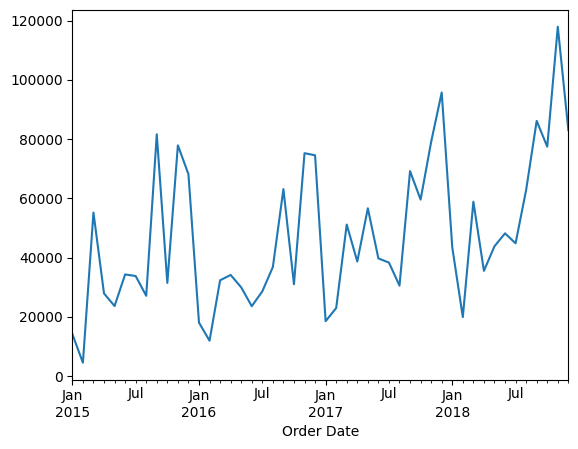

In [64]:
sales_by_month = df.set_index('Order Date')['Sales'].resample('ME').sum()
sales_by_month.plot()

## Pandas String Operations

In [67]:
x = np.array([2, 3, 5, 7, 11, 13])
x

array([ 2,  3,  5,  7, 11, 13])

In [ ]:
x ** 2

# alternatively
x_squared = np.power(x, 2)

array([  4,   9,  25,  49, 121, 169])

## Vectorized String Operations

In [71]:
data = ['sheila', 'victor', 'annette', 'peris', 'willard']
data

['sheila', 'victor', 'annette', 'peris', 'willard']

In [72]:
[s.capitalize() for s in data]

['Sheila', 'Victor', 'Annette', 'Peris', 'Willard']

In [74]:
names = pd.Series(data)
names

0     sheila
1     victor
2    annette
3      peris
4    willard
dtype: str

In [75]:
names.str.capitalize()

0     Sheila
1     Victor
2    Annette
3      Peris
4    Willard
dtype: str

In [76]:
full_names = ['Sheila Wanjiru', 'Victor Kirui', 'Annette Njeri', 'Peris Wanjiru', 'Willard Owiti']
full_names

['Sheila Wanjiru',
 'Victor Kirui',
 'Annette Njeri',
 'Peris Wanjiru',
 'Willard Owiti']

In [78]:
full_names_series = pd.Series(full_names)
full_names_series

0    Sheila Wanjiru
1      Victor Kirui
2     Annette Njeri
3     Peris Wanjiru
4     Willard Owiti
dtype: str

In [79]:
full_names_series.str.split()

0    [Sheila, Wanjiru]
1      [Victor, Kirui]
2     [Annette, Njeri]
3     [Peris, Wanjiru]
4     [Willard, Owiti]
dtype: object

In [80]:
full_names_series.str.upper()

0    SHEILA WANJIRU
1      VICTOR KIRUI
2     ANNETTE NJERI
3     PERIS WANJIRU
4     WILLARD OWITI
dtype: str

In [82]:
[len(s) for s in full_names]

[14, 12, 13, 13, 13]

In [83]:
full_names_series.str.len()

0    14
1    12
2    13
3    13
4    13
dtype: int64

In [86]:
full_names_series.str.startswith('V')

0    False
1     True
2    False
3    False
4    False
dtype: bool

In [89]:
full_names_series.str.endswith('i')

0    False
1     True
2     True
3    False
4     True
dtype: bool